In [2]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
fdtdApi = lumapi.FDTD(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Geometria

In [3]:
microns = 1e-6
wg_height = 0.22 *microns
wg_len = 22 * microns
wg_width1 = 0.39 *microns # Suporta TE0
wg_width2 = 0.82 *microns # Suporta TE1
gap = 0.2 * microns

In [4]:
fdtdApi.addrect()
fdtdApi.set("name", "wg1")
fdtdApi.set("x", -1.25 *microns)
fdtdApi.set("y", 0)
fdtdApi.set("z", 0)
fdtdApi.set("x span", wg_len - 2.5*microns)
fdtdApi.set("y span", wg_width1)
fdtdApi.set("z span", wg_height)
fdtdApi.set("material", "Si (Silicon) - Palik")

fdtdApi.addrect()
fdtdApi.set("name", "wg2")
fdtdApi.set("x", 1.25 *microns)
fdtdApi.set("y", -(wg_width1/2 + gap + wg_width2/2))
fdtdApi.set("z", 0)
fdtdApi.set("x span", wg_len - 2.5 *microns)
fdtdApi.set("y span", wg_width2)
fdtdApi.set("z span", wg_height)
fdtdApi.set("material", "Si (Silicon) - Palik")

Solver

In [5]:
solver_x_span = wg_len - 1 *microns
solver_y_span = (wg_width1 + wg_width2 + gap) + 4*microns
solver_z_span = wg_height + 3 *microns

In [6]:
fdtdApi.addfdtd()
fdtdApi.set("background material", "SiO2 (Glass) - Palik")

fdtdApi.set("x", 0)
fdtdApi.set("y", -(wg_width1 + wg_width2 + gap)/2 + wg_width1/2) # Centro do dispositivo
fdtdApi.set("z", 0)
fdtdApi.set("x span",solver_x_span)
fdtdApi.set("y span", solver_y_span)
fdtdApi.set("y span", solver_z_span)

fdtdApi.set('global source wavelength start', 1.5 *microns)
fdtdApi.set('global source wavelength stop', 1.6 *microns)
fdtdApi.set('global monitor frequency points', 21)
fdtdApi.set('Mesh accuracy', 4)
fdtdApi.set('simulation time', 3.5*(10**(-12)))

In [7]:
fdtdApi.addport()
fdtdApi.set('name', 'input')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', fdtdApi.getnamed("FDTD", "x min") + 0.5 *microns)
fdtdApi.set('y', 0)
fdtdApi.set('z', 0)
fdtdApi.set('y span', 2 *microns)
fdtdApi.set('z span', 2 *microns)

In [8]:
fdtdApi.addport()
fdtdApi.set('name', 'output')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', fdtdApi.getnamed("FDTD", "x max") - 0.5 *microns)
fdtdApi.set('y', fdtdApi.getnamed("wg2", "y"))
fdtdApi.set('z', 0)
fdtdApi.set('y span', 2 *microns)
fdtdApi.set('z span', 2 *microns)

In [9]:
fdtdApi.addprofile()
fdtdApi.set('name', 'profile')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', 21)
fdtdApi.set('x', 0)
fdtdApi.set('x span', solver_x_span)
fdtdApi.set('y', -(wg_width1 + wg_width2 + gap)/2 + wg_width1/2) # Centro do dispositivo
fdtdApi.set("z", 0)
fdtdApi.set('y span', solver_y_span)

In [10]:
fdtdApi.setnamed("FDTD", "y span", solver_y_span)
fdtdApi.setnamed("FDTD", "z span", solver_z_span)

In [14]:
fdtdApi.save('acoplador_conversor_FDTD')
fdtdApi.run()

Plotagem de perfil de campo

In [15]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2

In [16]:
indxLambda = 10
x_efield = fdtdApi.getdata("profile", "x")
y_efield = fdtdApi.getdata("profile", "y")
lmbd = nu2lambda(fdtdApi.getdata("profile", "f"))

xmin = np.min(x_efield) /microns
xmax = np.max(x_efield) /microns
ymin = np.min(y_efield) /microns
ymax = np.max(y_efield) /microns

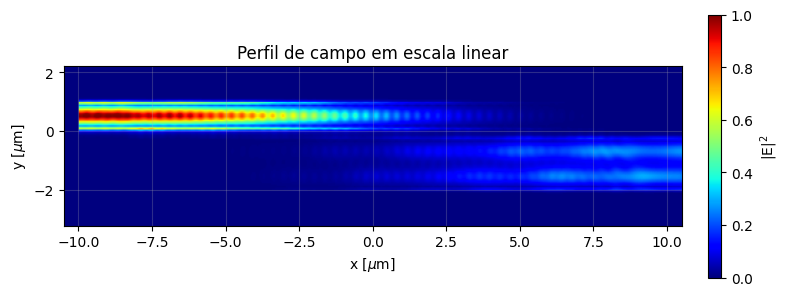

In [17]:
# Escala linear

fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField[:,:,indxLambda]), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=1)

colorbar = plt.colorbar(im1, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m]')
ax1.set_title("Perfil de campo em escala linear")

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

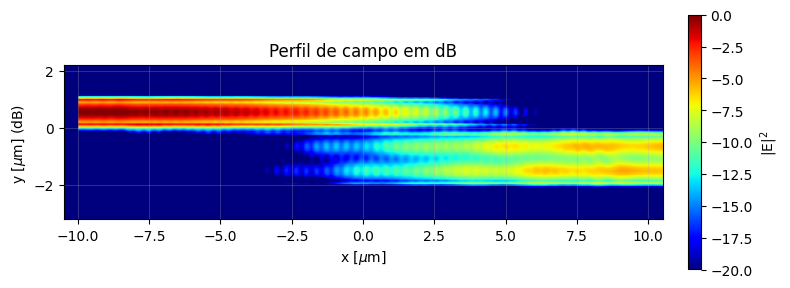

In [18]:
# Escala log

fig2 = plt.figure(figsize=(8,8))
ax1 = fig2.add_subplot(111)
im2 = ax1.imshow(10*np.log10(np.rot90(eField[:,:,indxLambda])), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=-20, vmax=0)

colorbar = plt.colorbar(im2, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m] (dB) ')
ax1.set_title("Perfil de campo em dB")

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

In [19]:
fdtdApi.switchtolayout()

# Diminuir tamanho dos guias 

fdtdApi.setnamed("wg1", "x max", 6 *microns)
fdtdApi.setnamed("wg2", "x min", -6 *microns)

In [20]:
fdtdApi.addobject("90_bend_wg")
fdtdApi.set("name", "bent_wg_1")
fdtdApi.set("first axis", "z")
fdtdApi.set("rotation 1", -90)
fdtdApi.set("x", fdtdApi.getnamed("wg1", "x max"))
fdtdApi.set("y", 5 *microns)
fdtdApi.set("z", 0)
fdtdApi.set("base height", wg_height)
fdtdApi.set("base width", wg_width1)
fdtdApi.set("radius", 5 *microns)
fdtdApi.set("material", "Si (Silicon) - Palik")

In [21]:
fdtdApi.addobject("90_bend_wg")
fdtdApi.set("name", "bent_wg_2")
fdtdApi.set("first axis", "z")
fdtdApi.set("rotation 1", 90)
fdtdApi.set("x", fdtdApi.getnamed("wg2", "x min"))
fdtdApi.set("y", fdtdApi.getnamed("wg2", "y") - 5*microns)
fdtdApi.set("z", 0)
fdtdApi.set("base height", wg_height)
fdtdApi.set("base width", wg_width2)
fdtdApi.set("radius", 5 *microns)
fdtdApi.set("material", "Si (Silicon) - Palik")

In [22]:
fdtdApi.setnamed("FDTD", "z span", solver_z_span)

In [23]:
# Para análise da conversão de modo

fdtdApi.addpower()
fdtdApi.set('name', 'power')
fdtdApi.set('x', fdtdApi.getnamed("FDTD", "x max") - 0.4 *microns)
fdtdApi.set('y', fdtdApi.getnamed("wg2", "y"))
fdtdApi.set('z', 0)
fdtdApi.set("monitor type", 5)
fdtdApi.set('y span', 2 *microns)
fdtdApi.set('z span', 2 *microns)


fdtdApi.addmodeexpansion()
fdtdApi.set('name', 'mode_expansion')
fdtdApi.set('x', fdtdApi.getnamed("FDTD", "x max") - 0.3 *microns)
fdtdApi.set('y', fdtdApi.getnamed("wg2", "y"))
fdtdApi.set('z', 0)
fdtdApi.set("monitor type", 1)
fdtdApi.set('y span', 2 *microns)
fdtdApi.set('z span', 2 *microns)

In [24]:
# configurações especiais do mode expansion
fdtdApi.select("mode_expansion")
fdtdApi.setexpansion("input", "power")
fdtdApi.set("mode selection", "user select")
fdtdApi.seteigensolver("use max index", 0)
fdtdApi.seteigensolver("n", 3.47656) 
fdtdApi.updatemodes(2)
fdtdApi.set("use wavelength spacing", 1) 
#fdtdApi.set("use source limits", 1) 
fdtdApi.set("wavelength center", 1.55*microns) 
fdtdApi.set("wavelength span", 1*microns) 

In [25]:
fdtdApi.save('acoplador_conversor_FDTD')
fdtdApi.run()

In [ ]:
fdtdApi.setnamed("FDTD", "z span", solver_z_span)

In [30]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2

indxLambda = 10
x_efield = fdtdApi.getdata("profile", "x")
y_efield = fdtdApi.getdata("profile", "y")
lmbd = nu2lambda(fdtdApi.getdata("profile", "f"))

xmin = np.min(x_efield) /microns
xmax = np.max(x_efield) /microns
ymin = np.min(y_efield) /microns
ymax = np.max(y_efield) /microns

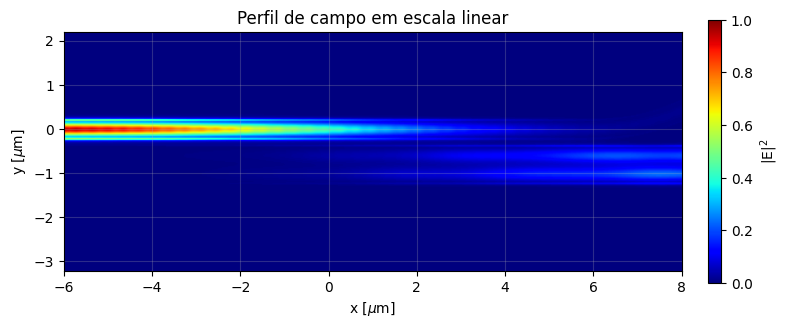

In [34]:
# Escala linear

fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField[:,:,indxLambda]), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=1)

colorbar = plt.colorbar(im1, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m]')
ax1.set_title("Perfil de campo em escala linear")
ax1.set_xlim([-6, 8])

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

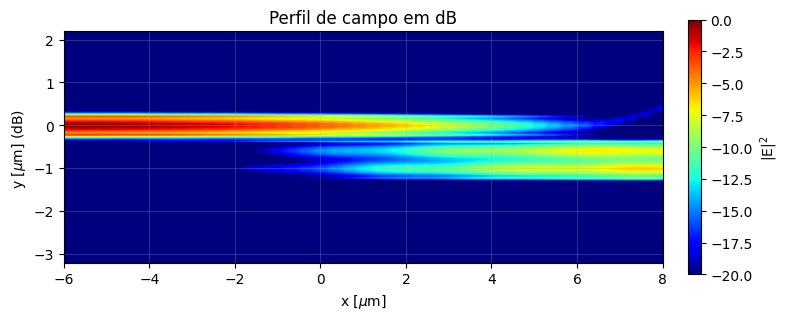

In [35]:
# Escala log

fig2 = plt.figure(figsize=(8,8))
ax1 = fig2.add_subplot(111)
im2 = ax1.imshow(10*np.log10(np.rot90(eField[:,:,indxLambda])), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=-20, vmax=0)

colorbar = plt.colorbar(im2, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m] (dB) ')
ax1.set_title("Perfil de campo em dB")
ax1.set_xlim([-6, 8])

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

In [36]:
eField2 = np.abs(np.squeeze(fdtdApi.getelectric('profile')))

indxLambda = 10
x_efield = fdtdApi.getdata("profile", "x")
y_efield = fdtdApi.getdata("profile", "y")
lmbd = nu2lambda(fdtdApi.getdata("profile", "f"))

xmin = np.min(x_efield) /microns
xmax = np.max(x_efield) /microns
ymin = np.min(y_efield) /microns
ymax = np.max(y_efield) /microns

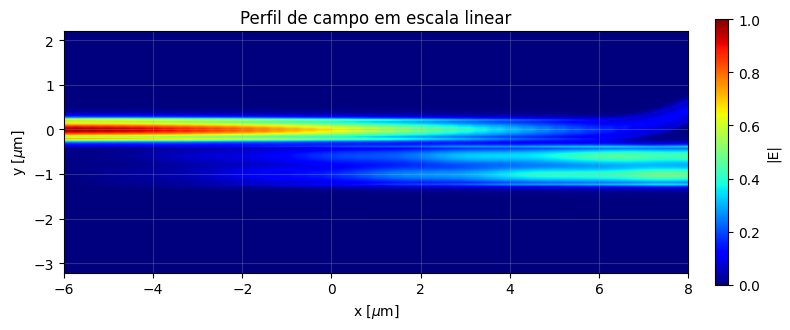

In [38]:
# Escala linear 

fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField2[:,:,indxLambda]), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=1)

colorbar = plt.colorbar(im1, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m]')
ax1.set_title("Perfil de campo em escala linear")
ax1.set_xlim([-6, 8])

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

Eficiência de conversão para modo TE1

In [44]:
res = fdtdApi.getresult("mode_expansion", "expansion for input")
T_forward = np.flip(res["T_forward"])
lamb = np.linspace(1.5, 1.6, 21)

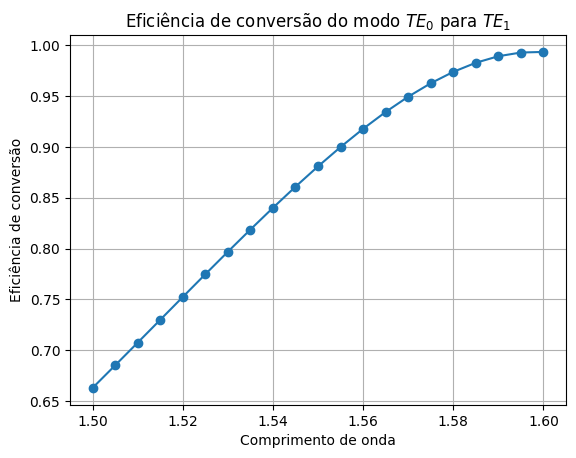

In [45]:
plt.plot(lamb, T_forward, 'o-')
plt.xlabel("Comprimento de onda")
plt.ylabel("Eficiência de conversão")
plt.title(r"Eficiência de conversão do modo $TE_0$ para $TE_1$")
plt.grid()

Eficiência em função do gap

In [50]:
gapvec = np.linspace(0.15*microns, 0.25*microns, 11)
conveff = np.zeros(len(gapvec))

for i in range(len(gapvec)):
    fdtdApi.switchtolayout()
    # Atualizando geometria do dispositivo

    fdtdApi.setnamed("wg2", "y", -(wg_width1/2 + gapvec[i] + wg_width2/2))
    fdtdApi.setnamed("bent_wg_2", "y", fdtdApi.getnamed("wg2", "y") - 5*microns)
    
    # atualizando solver

    solver_y_span = (wg_width1 + wg_width2 + gapvec[i]) + 4*microns

    fdtdApi.setnamed("FDTD", "y", -(wg_width1 + wg_width2 + gapvec[i])/2 + wg_width1/2) # Centro do dispositivo    
    fdtdApi.setnamed("FDTD", "y span", solver_y_span)
    fdtdApi.setnamed("FDTD::ports::output", 'y', fdtdApi.getnamed("wg2", "y"))
    fdtdApi.setnamed("profile", 'y', -(wg_width1 + wg_width2 + gapvec[i])/2 + wg_width1/2) # Centro do dispositivo
    fdtdApi.setnamed("profile", "y span", solver_y_span)
    fdtdApi.setnamed("power", 'y', fdtdApi.getnamed("wg2", "y"))
    fdtdApi.setnamed("mode_expansion", 'y', fdtdApi.getnamed("wg2", "y"))

    fdtdApi.redraw()
    fdtdApi.run(3)

    res = fdtdApi.getresult("mode_expansion", "expansion for input")

    T_forward = res["T_forward"]

    conveff[i] = T_forward[10, 0]

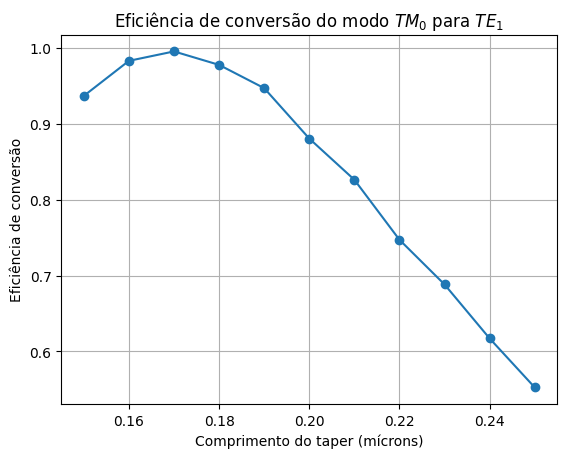

In [52]:
plt.plot(gapvec/microns, conveff, 'o-')
plt.xlabel("Comprimento do taper (mícrons)")
plt.ylabel("Eficiência de conversão")
plt.title(r"Eficiência de conversão do modo $TM_0$ para $TE_1$")
plt.grid()

Dispositivo final

In [53]:
fdtdApi.switchtolayout()
# Atualizando geometria do dispositivo

fdtdApi.setnamed("wg2", "y", -(wg_width1/2 + 0.17*microns + wg_width2/2))
fdtdApi.setnamed("bent_wg_2", "y", fdtdApi.getnamed("wg2", "y") - 5*microns)

# atualizando solver

solver_y_span = (wg_width1 + wg_width2 + 0.17*microns) + 4*microns

fdtdApi.setnamed("FDTD", "y", -(wg_width1 + wg_width2 + 0.17*microns)/2 + wg_width1/2) # Centro do dispositivo    
fdtdApi.setnamed("FDTD", "y span", solver_y_span)
fdtdApi.setnamed("FDTD::ports::output", 'y', fdtdApi.getnamed("wg2", "y"))
fdtdApi.setnamed("profile", 'y', -(wg_width1 + wg_width2 + 0.17*microns)/2 + wg_width1/2) # Centro do dispositivo
fdtdApi.setnamed("profile", "y span", solver_y_span)
fdtdApi.setnamed("power", 'y', fdtdApi.getnamed("wg2", "y"))
fdtdApi.setnamed("mode_expansion", 'y', fdtdApi.getnamed("wg2", "y"))

In [55]:
fdtdApi.save('acoplador_conversor_FDTD')
fdtdApi.run()

In [56]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile')))**2

indxLambda = 10
x_efield = fdtdApi.getdata("profile", "x")
y_efield = fdtdApi.getdata("profile", "y")
lmbd = nu2lambda(fdtdApi.getdata("profile", "f"))

xmin = np.min(x_efield) /microns
xmax = np.max(x_efield) /microns
ymin = np.min(y_efield) /microns
ymax = np.max(y_efield) /microns

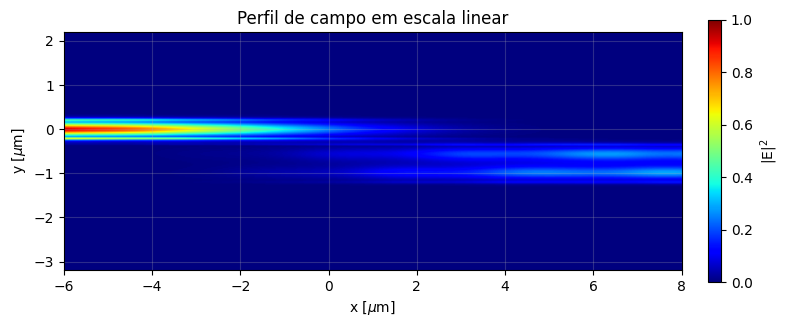

In [57]:
# Escala linear

fig1 = plt.figure(figsize=(8,8))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(np.rot90(eField[:,:,indxLambda]), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=1)

colorbar = plt.colorbar(im1, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m]')
ax1.set_title("Perfil de campo em escala linear")
ax1.set_xlim([-6, 8])

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

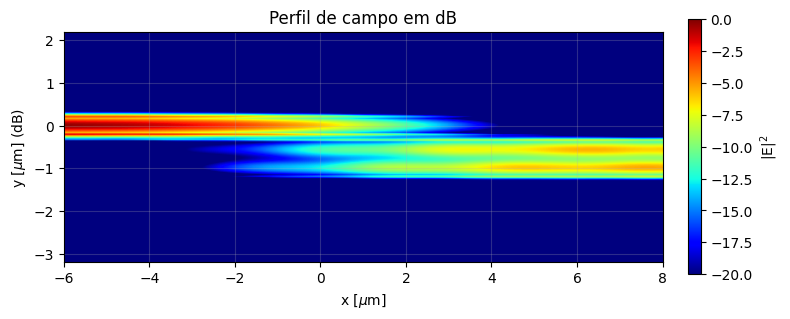

In [58]:
# Escala log

fig2 = plt.figure(figsize=(8,8))
ax1 = fig2.add_subplot(111)
im2 = ax1.imshow(10*np.log10(np.rot90(eField[:,:,indxLambda])), cmap='jet', extent=[xmin, xmax, ymin, ymax], vmin=-20, vmax=0)

colorbar = plt.colorbar(im2, fraction=0.02, pad=0.04)
colorbar.set_label(r'|E|$^2$')

ax1.set_xlabel(r'x [$\mu$m]')
ax1.set_ylabel(r'y [$\mu$m] (dB) ')
ax1.set_title("Perfil de campo em dB")
ax1.set_xlim([-6, 8])

ax1.grid(which='major', alpha=0.25)

plt.tight_layout()
plt.show()

In [59]:
res = fdtdApi.getresult("mode_expansion", "expansion for input")
T_forward = np.flip(res["T_forward"])
lamb = np.linspace(1.5, 1.6, 21)

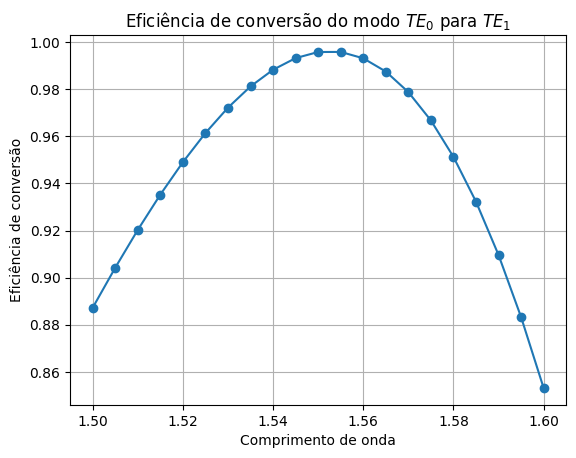

In [60]:
plt.plot(lamb, T_forward, 'o-')
plt.xlabel("Comprimento de onda")
plt.ylabel("Eficiência de conversão")
plt.title(r"Eficiência de conversão do modo $TE_0$ para $TE_1$")
plt.grid()

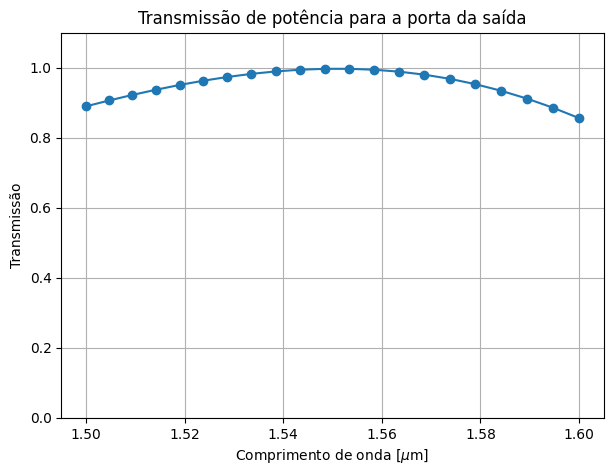

In [69]:
fig2 = plt.figure(figsize=(7,5))
ports = fdtdApi.getresult("FDTD::ports::output", "T")
plt.plot(ports['lambda']/microns, np.abs(ports['T']), 'o-')


plt.xlabel(r'Comprimento de onda [$\mu$m]')
plt.ylabel('Transmissão')
plt.title('Transmissão de potência para a porta da saída')

plt.ylim([0, 1.1])
plt.grid(True)
plt.show()

In [65]:
print(len(np.abs(ports['T'])))

21
